In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
import yaml
import time
from itertools import combinations
import gget
from scipy import sparse

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

# import scvi
# from scvi.external import SysVI

# import cupy as cp
# import cudf
# import rmm
# from rmm.allocators.cupy import rmm_cupy_allocator

# from cuml.manifold.umap import simplicial_set_embedding
# from scanpy.tools._utils import get_init_pos_from_paga 
# from cuml.manifold.umap import find_ab_params

# import warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)

# # Enable `managed_memory`
# rmm.reinitialize(
#     managed_memory=True,
#     pool_allocator=False,
# )

# cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

# Load in muscle dataset

Dataset (0116c625-ea28-4b87-836c-201b9f674bf8.h5ad) was downloaded from CellxGene, called 'Skeletal_muscle' from 'Automatic cell-type harmonization and integration across Human Cell Atlas datasets'.

human_limb_scRNAseq.h5ad (315d639c-ab99-4bbf-85ee-82263665614d.h5ad), also downloaded from CellxGene. From [A human embryonic limb cell atlas resolved in space and time (Nature 2023)](https://www.nature.com/articles/s41586-023-06806-x)

In [2]:
%%time

# fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxgene/0116c625-ea28-4b87-836c-201b9f674bf8.h5ad"
fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxgene/human_limb_scRNAseq.h5ad"

adata = sc.read_h5ad(fpath)
sc.logging.print_memory_usage()

adata

Memory usage: current 7.78 GB, difference +7.78 GB
CPU times: user 25.2 s, sys: 4.96 s, total: 30.2 s
Wall time: 31.2 s


/home/jrcwycy/miniconda3/envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 125955 × 26252
    obs: 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden', 'S_score', 'G2M_score', 'phase', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'adj_stage_colors', 'celltype_colors', 'celltype_sizes', 'citation', 'default_embedding', 'leiden', 'leiden_sizes', 'markers_celltype', 'markers_new_celltype', 'neighbors', 'new_celltype_sizes', 'organism', 'organism_ontology_term_id', 

In [3]:
adata.var.head()

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
gene_ids,,,,,,
ENSG00000243485,False,MIR1302-2HG,NCBITaxon:9606,gene,623,lncRNA
ENSG00000238009,False,ENSG00000238009,NCBITaxon:9606,gene,629,lncRNA
ENSG00000239945,False,ENSG00000239945,NCBITaxon:9606,gene,1319,lncRNA
ENSG00000236601,False,ENSG00000236601,NCBITaxon:9606,gene,607,lncRNA
ENSG00000235146,False,ENSG00000235146,NCBITaxon:9606,gene,504,lncRNA


In [5]:
adata.obs.head()

,percent_mito,n_counts,n_genes,doublet_scores,bh_pval,region,adj_stage,adj_sample,leiden,S_score,...,tissue_type,tissue_ontology_term_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
AAACCTGCACATTTCT-5386STDY7537944,0.011364,2992.0,1152,0.286585,0.872782,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,12,-0.117172,...,tissue,UBERON:0002103,mesenchymal cell,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,g!nA+E@sA(
AAACCTGCAGGGATTG-5386STDY7537944,0.006805,2939.0,1187,0.194631,0.872782,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,12,-0.104853,...,tissue,UBERON:0002103,osteoblast,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,L-jN6<dDh*
AAACCTGCATCGGGTC-5386STDY7537944,0.011667,6857.0,2329,0.098748,0.872782,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,12,0.033006,...,tissue,UBERON:0002103,mesenchymal cell,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,5P?|%v029%
AAACCTGCATGGGACA-5386STDY7537944,0.009933,10974.0,2967,0.185345,0.872782,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,12,0.106430,...,tissue,UBERON:0002103,mesenchymal cell,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,hhcuqnDpD{
AAACCTGGTGATGCCC-5386STDY7537944,0.015003,6532.0,2083,0.130000,0.927508,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,26,-0.120746,...,tissue,UBERON:0002103,vein endothelial cell,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,vj@>rw_0Y}


In [6]:
adata.obs[['celltype', 'cell_type', 'tissue']].head()

,celltype,cell_type,tissue
AAACCTGCACATTTCT-5386STDY7537944,Mes1,mesenchymal cell,hindlimb
AAACCTGCAGGGATTG-5386STDY7537944,OCP,osteoblast,hindlimb
AAACCTGCATCGGGTC-5386STDY7537944,Mes1,mesenchymal cell,hindlimb
AAACCTGCATGGGACA-5386STDY7537944,Mes1,mesenchymal cell,hindlimb
AAACCTGGTGATGCCC-5386STDY7537944,VenousEndo,vein endothelial cell,hindlimb


In [7]:
adata.obs['cell_type'].value_counts()

cell_type
mesenchymal cell                        49216
fibroblast of dermis                    14105
chondrocyte                             12599
skeletal muscle myoblast                10584
muscle fibroblast                        7010
osteoblast                               5804
fibroblast                               4650
chondroblast                             3356
primitive red blood cell                 1963
muscle cell                              1947
tendon cell                              1655
basal cell                               1343
vein endothelial cell                    1307
connective tissue cell                   1247
smooth muscle cell                       1208
myoblast                                 1157
Schwann cell                             1075
pericyte                                 1026
Schwann cell precursor                    960
peridermal cell                           817
macrophage                                588
articular chondrocyte   

In [8]:
# cell_types = [
#     'fast muscle cell', 
#     'slow muscle cell', 
#     'skeletal muscle satellite stem cell', 
#     'cell of skeletal muscle', 
#     'fibroblast',
# ]

cell_types = [
    'fibroblast of dermis',
    'fibroblast',
    'muscle fibroblast',
    'skeletal muscle myoblast',
    'myoblast',
    'muscle cell',
]

adata = adata[adata.obs['cell_type'].isin(cell_types)].copy()

adata

AnnData object with n_obs × n_vars = 39453 × 26252
    obs: 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden', 'S_score', 'G2M_score', 'phase', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'adj_stage_colors', 'celltype_colors', 'celltype_sizes', 'citation', 'default_embedding', 'leiden', 'leiden_sizes', 'markers_celltype', 'markers_new_celltype', 'neighbors', 'new_celltype_sizes', 'organism', 'organism_ontology_term_id', '

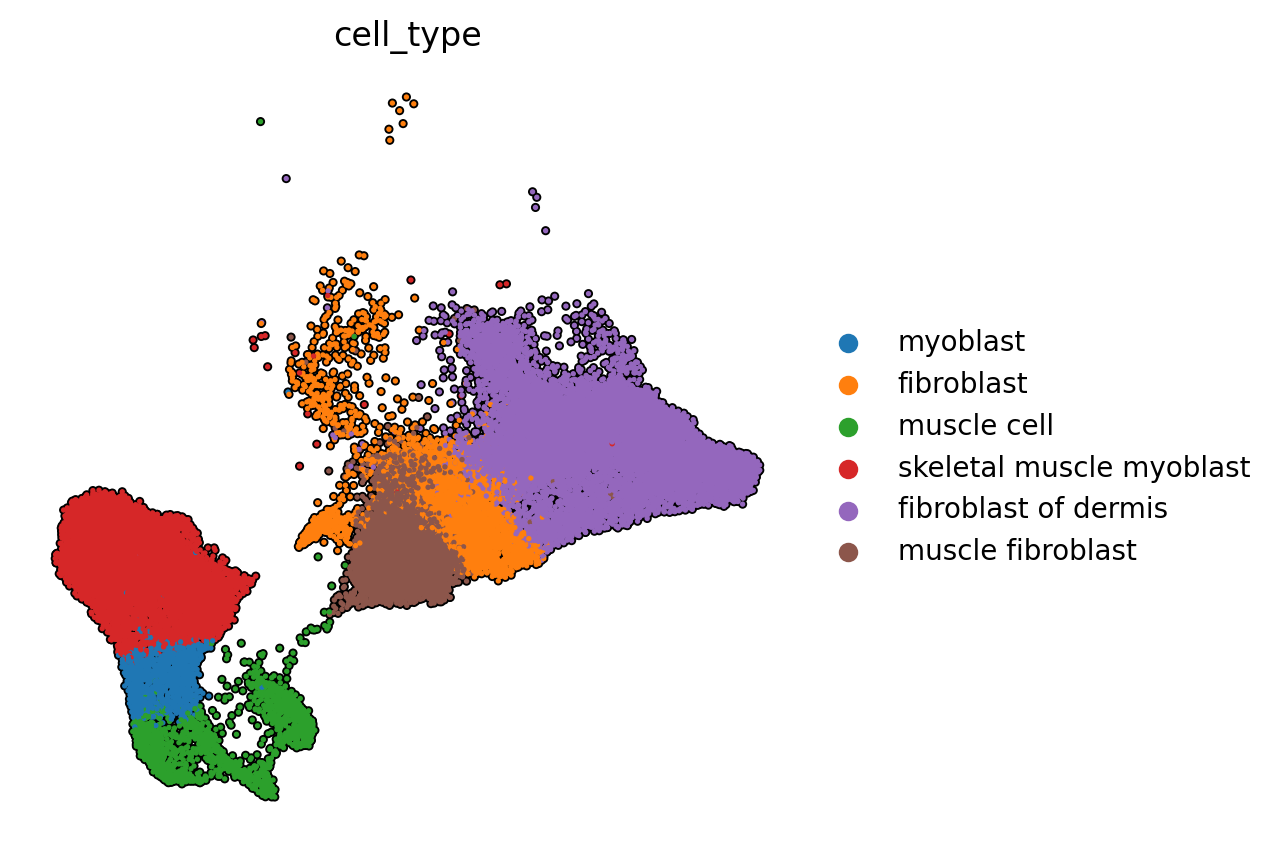

In [9]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sc.pl.umap(
    adata,
    color='cell_type',
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Load in processed anndata

In [10]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
bdata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
bdata

Memory usage: current 16.88 GB, difference +3.92 GB
CPU times: user 254 ms, sys: 1.07 s, total: 1.33 s
Wall time: 4.22 s


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

#

In [ ]:
# rsc.get.anndata_to_GPU(adata)
# rsc.pp.filter_cells(adata, min_counts=200)
# rsc.pp.filter_genes(adata, min_counts=50)

# adata.layers['counts'] = adata.X.get()

# rsc.pp.normalize_total(adata, target_sum=1e4)
# rsc.pp.log1p(adata)

# adata.layers['log_norm'] = adata.X.get()

# rsc.get.anndata_to_CPU(adata) # move to GPU
# adata

In [ ]:
# adata.raw = adata  # keep full dimension safe
# print(f"Number of genes before HVG selection: {adata.n_vars}")

# rsc.get.anndata_to_GPU(adata)

# rsc.pp.highly_variable_genes(
#     adata, 
#     batch_key="cell_type",
# )

# adata = adata[:, adata.var['highly_variable']].copy()

# print(f"Number of genes after HVG selection: {adata.n_vars}")

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 5, 4
# sc.pl.highly_variable_genes(
#     adata
# )

# adata

In [ ]:
# rsc.get.anndata_to_CPU(adata)

# sc.pp.pca(
#     adata,
# )

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 5, 3
# sc.pl.pca_variance_ratio(
#     adata
# )

# adata

In [ ]:
# # rsc.get.anndata_to_GPU(adata)

# # rsc.pp.neighbors(
# #     adata,
# # )

# # rsc.tl.umap(
# #     adata,
# # )

# # rsc.tl.leiden(
# #     adata,
# #     resolution=0.35,
# # )

# # rsc.get.anndata_to_CPU(adata)

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 10, 10


# sc.pl.umap(
#     adata,
#     color=['cell_type', 'leiden', 'Dataset'],
#     size=15,
#     ncols=1,
#     add_outline=True,
#     outline_color=('k', 'k'),
#     frameon=False,
# )